In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing the Dataset from kaggle

In [2]:
!kaggle competitions download -c dogs-vs-cats

  2%|▊                                      | 18.0M/812M [00:03<02:30, 5.55MB/s]
User cancelled operation
^C


In [4]:
# Extracting the compressed dataset
from zipfile import ZipFile
dataset ='Dataset/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print('Dataset Extracted')

Dataset Extracted


In [5]:
# Extracting the compressed dataset
from zipfile import ZipFile
dataset ='Dataset/train.zip'

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print('Dataset Extracted')

Dataset Extracted


In [6]:
import os

path, dirs, files = next(os.walk('Dataset/train'))
file_count = len(files)
print(file_count)

25000


Printing the name of images

In [7]:
file_names = os.listdir('Dataset/train')
print(file_names)

['cat.4813.jpg', 'dog.8000.jpg', 'dog.3477.jpg', 'cat.4868.jpg', 'cat.7504.jpg', 'dog.7117.jpg', 'dog.11529.jpg', 'dog.2746.jpg', 'cat.4116.jpg', 'dog.5348.jpg', 'dog.7243.jpg', 'cat.9059.jpg', 'cat.4367.jpg', 'cat.8494.jpg', 'cat.7988.jpg', 'cat.11914.jpg', 'dog.2826.jpg', 'dog.7372.jpg', 'cat.7889.jpg', 'dog.8285.jpg', 'cat.9413.jpg', 'cat.3929.jpg', 'dog.2251.jpg', 'dog.8748.jpg', 'cat.460.jpg', 'dog.1962.jpg', 'dog.2863.jpg', 'dog.9149.jpg', 'cat.5870.jpg', 'dog.7783.jpg', 'cat.5608.jpg', 'dog.1160.jpg', 'dog.9512.jpg', 'cat.11514.jpg', 'dog.2658.jpg', 'cat.2681.jpg', 'dog.12424.jpg', 'dog.11846.jpg', 'cat.10626.jpg', 'cat.7647.jpg', 'cat.3355.jpg', 'dog.6445.jpg', 'dog.9594.jpg', 'dog.5560.jpg', 'cat.6953.jpg', 'cat.10503.jpg', 'cat.10682.jpg', 'dog.5754.jpg', 'dog.6721.jpg', 'dog.5130.jpg', 'dog.2913.jpg', 'cat.10089.jpg', 'cat.8380.jpg', 'dog.9317.jpg', 'dog.3541.jpg', 'cat.5236.jpg', 'cat.8858.jpg', 'dog.725.jpg', 'cat.2451.jpg', 'dog.11238.jpg', 'dog.7646.jpg', 'cat.11839.jpg'

Importing the Dependencies

In [8]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import cv2

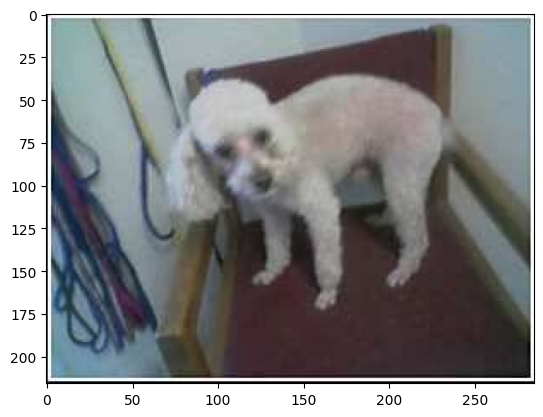

In [9]:
img = mpimg.imread('Dataset/train/dog.8000.jpg')
imgplot = plt.imshow(img)


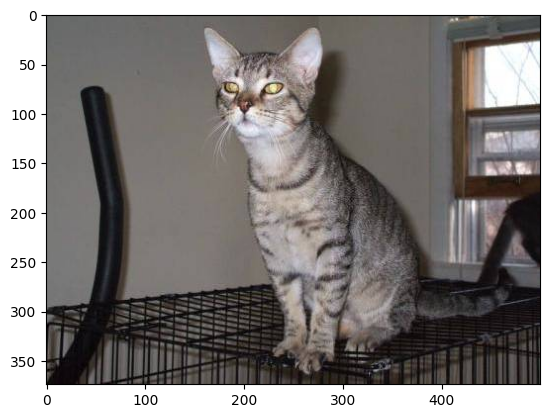

In [10]:
img = mpimg.imread('Dataset/train/cat.4813.jpg')
imgplot = plt.imshow(img)

In [11]:
file_names = os.listdir('Dataset/train/')

for i in range(5):
    name = file_names[i]
    print(name[0:3])


cat
dog
dog
cat
cat


In [12]:
file_names = os.listdir('Dataset/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:
    name = img_file[0:3]

    if name == 'dog':
        dog_count += 1
    else:
        cat_count +=1
print('Number of dog = ', dog_count)
print('Number of cat = ', cat_count)


Number of dog =  12500
Number of cat =  12500


Resizing the images

In [13]:
os.mkdir('Dataset/Resized')

FileExistsError: [Errno 17] File exists: 'Dataset/Resized'

In [14]:
os.makedirs('Dataset/Resized', exist_ok=True)

original_folder = 'Dataset/train/'
resized_folder = 'Dataset/Resized/'

files = os.listdir(original_folder)

for i in range(2000):
    filename = files[i]
    img_path = os.path.join(original_folder, filename)

    img = Image.open(img_path)
    img = img.resize((224, 224))
    img = img.convert('RGB')

    new_img_path = os.path.join(resized_folder, filename)
    img.save(new_img_path)


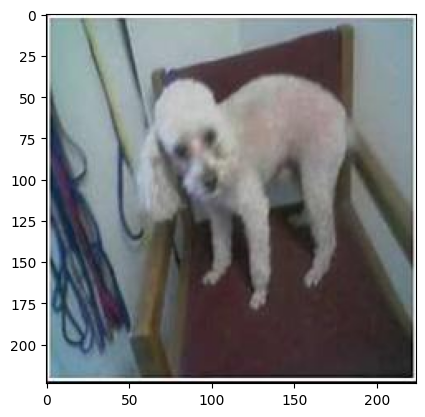

In [15]:
img = mpimg.imread('Dataset/Resized/dog.8000.jpg')
imgplot = plt.imshow(img)


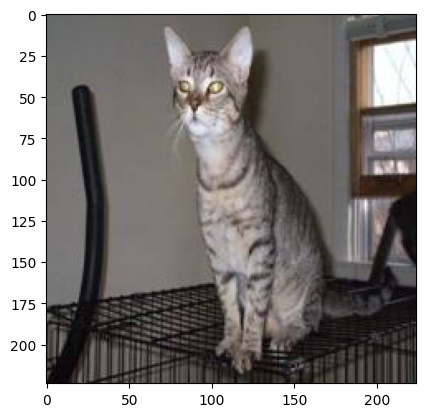

In [16]:
img = mpimg.imread('Dataset/Resized/cat.4813.jpg')
imgplot = plt.imshow(img)

Creating labels for resized images

Cat --> 0

Dog --> 1

In [17]:
# Creating af or loop to assign labels
filenames = os.listdir('Dataset/Resized/')


labels = []

for i in range(2000):
    file_name = filenames[i]
    label = file_name[0:3]

    if label == 'dog':
        labels.append(1)
    else:
        labels.append(0)


In [18]:
filenames[0:5]

['cat.4813.jpg',
 'dog.8000.jpg',
 'dog.3477.jpg',
 'cat.4868.jpg',
 'cat.7504.jpg']

In [19]:
labels[0:5]

[0, 1, 1, 0, 0]

In [20]:
# Counting the images of dogs and cats in 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[ 991 1009]


Images to numpy arrays

In [21]:
import glob


In [22]:
image_directory = 'Dataset/Resized/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [23]:
print(dog_cat_images[0:5])

[[[[102 103 101]
   [102 103 101]
   [102 103 101]
   ...
   [ 94  91  87]
   [ 94  89  86]
   [ 93  88  85]]

  [[102 103 101]
   [102 103 101]
   [103 104 102]
   ...
   [ 90  87  83]
   [ 90  85  82]
   [ 89  84  81]]

  [[102 103 101]
   [103 104 102]
   [103 104 102]
   ...
   [ 84  79  76]
   [ 83  78  75]
   [ 83  78  75]]

  ...

  [[ 69  76  79]
   [ 24  31  34]
   [  6   9  13]
   ...
   [ 65  67  68]
   [ 24  26  26]
   [ 61  63  63]]

  [[ 36  43  46]
   [  9  16  19]
   [  6   9  13]
   ...
   [ 65  67  68]
   [ 24  26  26]
   [ 60  62  62]]

  [[ 11  18  21]
   [  4  11  14]
   [ 14  17  21]
   ...
   [ 66  68  69]
   [ 24  26  26]
   [ 60  62  62]]]


 [[[ 11   3  20]
   [ 45  38  53]
   [ 12   2  14]
   ...
   [ 10   8   7]
   [ 15  16  14]
   [  1   2   0]]

  [[ 82  75  90]
   [210 203 216]
   [228 219 229]
   ...
   [234 233 229]
   [235 234 230]
   [221 222 218]]

  [[ 56  50  61]
   [250 245 254]
   [254 246 253]
   ...
   [235 235 229]
   [250 250 244]
   [255 255

In [24]:
type(dog_cat_images)

numpy.ndarray

In [25]:
dog_cat_images.shape

(2000, 224, 224, 3)

In [26]:
X = dog_cat_images
Y = np.asarray(labels)

Train Test Split

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [28]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


In [29]:
X_train_scaled = X_train.astype('float32') / 255.0
X_test_scaled = X_test.astype('float32') / 255.0

In [30]:
Y_train = Y_train.astype('int32')
Y_test = Y_test.astype('int32')


Building the Neural Network

In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 without the top classifier layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base layers
base_model.trainable = False


In [32]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
history = model.fit(
    X_train_scaled, Y_train,
    validation_data=(X_test_scaled, Y_test),
    epochs=10,
    batch_size=32
)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 568ms/step - accuracy: 0.8175 - loss: 0.4190 - val_accuracy: 0.9575 - val_loss: 0.1323
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 535ms/step - accuracy: 0.9394 - loss: 0.1761 - val_accuracy: 0.9725 - val_loss: 0.0910
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 530ms/step - accuracy: 0.9538 - loss: 0.1212 - val_accuracy: 0.9725 - val_loss: 0.0766
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 534ms/step - accuracy: 0.9669 - loss: 0.0918 - val_accuracy: 0.9700 - val_loss: 0.0690
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 532ms/step - accuracy: 0.9694 - loss: 0.0843 - val_accuracy: 0.9750 - val_loss: 0.0644
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 540ms/step - accuracy: 0.9737 - loss: 0.0754 - val_accuracy: 0.9725 - val_loss: 0.0594
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 536ms/step - accuracy: 0.9756 - loss: 0.0630 - val_accuracy: 0.9700 - val_loss: 0.0587
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 533ms/step - accuracy: 0.9769 - loss: 0.0601 - val_accu

In [34]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss = ', score)
print('Test Accuracy = ', acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 463ms/step - accuracy: 0.9700 - loss: 0.0585
Test Loss =  0.05845464766025543
Test Accuracy =  0.9700000286102295


In [ ]:
def predict_image(img_path, model):
    """
    Predict whether the input image is a cat or dog.
    
    Parameters:
    - img_path: path to the image file
    - model: trained Keras model
    
    Returns:
    - class_name: 'Dog' or 'Cat'
    - probability: confidence score
    """
    # Load the image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    # Normalize and expand dimensions
    img_array = np.expand_dims(img.astype(np.float32)/255.0, axis=0)  # shape: (1,224,224,3)
    
    # Predict
    pred = model.predict(img_array)
    class_index = np.argmax(pred)  # 0 or 1
    class_name = 'Dog' if class_index == 1 else 'Cat'
    probability = float(np.max(pred))
    
    return class_name, probability